In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import optuna

In [18]:
df = pd.read_excel('data/input.xlsx')

In [19]:
df['годы'] = pd.to_numeric(df['годы'], errors='coerce')
df['flag_ussr_collapse'] = df['годы'].apply(lambda x: 1 if x == 1991 else 0)
df['flag_crisis_2008'] = df['годы'].apply(lambda x: 1 if x in [2008, 2009] else 0)
df['flag_covid'] = df['годы'].apply(lambda x: 1 if x in [2020, 2021] else 0)

In [20]:
import numpy as np
import pandas as pd

# Данные о ВВП по годам
years_vvp = np.array([1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 
                      2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024])

vvp_values = np.array([1428.5, 2007.8, 2342.5, 2629.6, 4823.2, 7305.6, 8943.6, 10830.5, 13208.2, 17027.2, 
                       21609.8, 26917.2, 33247.5, 41276.8, 38807.2, 46308.5, 60114.0, 68103.4, 72985.7, 
                       79030.0, 83087.4, 85616.1, 91843.2, 103861.7, 109608.3, 107658.1, 134727.5, 
                       156940.9, 176413.6, 201152.1])



# Подставим данные ВВП для существующих годов
df['vvp'] = np.interp(df['годы'], years_vvp, vvp_values)


# 1991-1999 - Положительные значения (кризисные годы)
# 2000-2007 - Отрицательные значения (рост экономики и стабилизация)
# 2008-2015 - Положительные значения (кризисы, санкции)
# 2020 - Положительное значение (пандемия)
years = [
    1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999,  # 1991-1999
    2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008,  # 2000-2007
    2009, 2010, 2011, 2012, 2013, 2014, 2015,  # 2008-2015
    2020  # 2020
]

crisis = [
    10, 10, 10, 15, 20, 10, 10, 10, 30,  # 1991-1999
    0, 0, -5, -10, -15, 0, -5, -5, -10,  # 2000-2007
    25, 10, 0, -5, -5,  # 2008-2015
    15  # 2020
]

# Добавим столбец кризиса в DataFrame df
df['crisis'] = df['годы'].map(dict(zip(years, crisis))).fillna(0)

# Массив коэффициентов войн и соответствующие годы
war = [
    0, 0, 0, 5, 10,  # 1991-1995 (локальные конфликты, перемирие)
    10, 15, 20, 15, 0,  # 1996-2000 (вторая чеченская война)
    25, 30, 20, 15, 10,  # 2001-2005 (миротворческие операции)
    10, 10, 5, 0, 0,  # 2006-2010 (участие в Сирии, другие конфликты)
    20, 30, 40, 40,  # 2011-2015 (активные операции в Сирии и на Украине)
    50  # 2020 (конфликт на Украине)
]

# Добавим столбец кризиса в DataFrame df
df['war'] = df['годы'].map(dict(zip(years, war))).fillna(0)
df



,годы,Всего браков,М до 18,М 18-24,М 25-34,М 35 и более,М не указан,Ж до 18,Ж 18-24,Ж 25-34,Ж 35 и более,Ж не указан,flag_ussr_collapse,flag_crisis_2008,flag_covid,vvp,crisis,war
0,1960,1499581,226,798207,468734,232012,402,5015,949816,320916,223208,626,0,0,0,1428.5,0.0,0.0
1,1970,1319227,2464,809466,328416,178797,84,19227,933308,201485,165041,166,0,0,0,1428.5,0.0,0.0
2,1980,1464579,5115,902610,369768,187027,59,32591,1000767,272157,158944,120,0,0,0,1428.5,0.0,0.0
3,1990,1319928,13536,692941,389739,223628,84,72073,779437,273108,195227,83,0,0,0,1428.5,0.0,0.0
4,1991,1277232,13506,671857,367477,224314,78,81035,746538,253344,196240,75,1,0,0,1428.5,10.0,0.0
5,1992,1053717,10611,561052,288860,193113,81,72697,615119,197645,168177,79,0,0,0,1428.5,10.0,0.0
6,1993,1106723,9837,605349,295350,196116,71,75936,660105,200753,169863,66,0,0,0,1428.5,10.0,0.0
7,1994,1080600,8844,578305,293623,199774,54,69237,638631,200070,172605,57,0,0,0,1428.5,15.0,5.0
8,1995,1075219,8044,555859,303953,207319,44,63633,628329,205549,177655,53,0,0,0,1428.5,20.0,10.0
9,1996,866651,6167,430853,254362,175246,23,47481,500163,170058,148921,28,0,0,0,2007.8,10.0,10.0


In [30]:
# Функция для получения фичей по case_number
def get_features(df, case_number):
    match case_number:
        case 1:
            return df[['годы', 'crisis', 'war']].values
        case 2:
            return df[['годы', 'crisis', 'war', 'flag_ussr_collapse']].values
        case 3:
            return df[['годы', 'crisis', 'war', 'flag_crisis_2008']].values
        case 4:
            return df[['годы', 'crisis', 'war', 'flag_covid']].values
        case 5:
            return df[['годы', 'crisis', 'war', 'flag_ussr_collapse', 'flag_crisis_2008']].values
        case 6:
            return df[['годы', 'crisis', 'war', 'flag_ussr_collapse', 'flag_covid']].values
        case 7:
            return df[['годы', 'crisis', 'war', 'flag_crisis_2008', 'flag_covid']].values
        case 8:
            return df[['годы', 'crisis', 'war', 'flag_ussr_collapse', 'flag_crisis_2008', 'flag_covid']].values
        case _:
            raise ValueError(f"Invalid case number: {case_number}")

In [24]:
# Функция подготовки данных
def prepare_data(df, case_number):
    x = get_features(df, case_number)
    y = df['Всего браков'].values.reshape(-1, 1)

    # Нормализация данных
    scaler_x = MinMaxScaler()
    scaler_y = MinMaxScaler()
    x = scaler_x.fit_transform(x)
    y = scaler_y.fit_transform(y)

    # Переводим в тензоры
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    x = torch.tensor(x, dtype=torch.float32).to(device)
    y = torch.tensor(y, dtype=torch.float32).to(device)

    return x, y, scaler_x, scaler_y, device

In [25]:
# Функция обучения модели
def train(model, x, y, num_epochs=80
          , lr=0.005):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    for epoch in range(num_epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        if (epoch + 1) % 1000 == 0:
            print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}')
    return model

In [26]:
# Функция построения модели
class NetActivate(nn.Module):
    def __init__(self, input_dim):
        super(NetActivate, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 100),
            nn.ReLU(),
            nn.Linear(100, 100),
            nn.ReLU(),
            nn.Linear(100, 100),
            nn.ReLU(),
            nn.Linear(100, 100),
            nn.ReLU(),
            nn.Linear(100, 1)
        )

    def forward(self, x):
        return self.model(x)

In [37]:
# # Функция для генерации новых лет
# def generate_years(start_year, num_years, case_number):
#     years = np.array([start_year + i for i in range(1, num_years + 1)]).reshape(-1, 1)
# 
#     # Количество флагов зависит от case_number
#     if case_number == 1:
#         num_flags = 0
#     elif case_number in {2, 3, 4}:
#         num_flags = 1
#     elif case_number in {5, 6, 7}:
#         num_flags = 2
#     elif case_number == 8:
#         num_flags = 3
#     else:
#         raise ValueError(f"Invalid case number: {case_number}")
#     num_flags += 2
#     # Создаем массив флагов
#     zeros = np.zeros((years.shape[0], num_flags))  # добавляем флаги
#     return np.hstack((years, zeros))  # возвращаем годы и флаги

In [60]:
def generate_years(start_year, num_years, case_number, df_coeffs):
    years = np.array([start_year + i for i in range(1, num_years + 1)]).reshape(-1, 1)
    years_df = pd.DataFrame(years, columns=['year'])

    # Количество флагов зависит от case_number
    if case_number == 1:
        num_flags = 0
    elif case_number in {2, 3, 4}:
        num_flags = 1
    elif case_number in {5, 6, 7}:
        num_flags = 2
    elif case_number == 8:
        num_flags = 3
    else:
        raise ValueError(f"Invalid case number: {case_number}")
    num_flags += 2

    if num_flags == 0:
        flags = np.empty((years.shape[0], 0))
    else:
        # Забираем коэффициенты для нужных лет
        merged = years_df.merge(df_coeffs, on='year', how='left')

        # Если каких-то лет нет в df_coeffs — можно заполнить нулями
        merged.fillna(0, inplace=True)

        # Берем только нужное количество флагов
        flag_cols = merged.columns[1:1+num_flags]
        flags = merged[flag_cols].to_numpy()

    return np.hstack((years, flags))


In [51]:
# import numpy as np
# 
# # Функция для генерации коэффициента события
# def generate_event_coefficients(size):
#     coefficients = []
#     for _ in range(size):
#         event_type = np.random.choice(['good', 'bad'], p=[0.4, 0.6])  # 40% хорошее, 60% плохое
#         if event_type == 'good':
#             coeff = -np.random.uniform(5, 20)  # отрицательные коэффициенты для хороших событий
#         else:
#             coeff = np.random.uniform(5, 30)   # положительные коэффициенты для плохих событий
#         coefficients.append(coeff)
#     return np.array(coefficients)
# 
# # Функция для генерации новых лет с коэффициентами
# def generate_years(start_year, num_years, case_number):
#     years = np.array([start_year + i for i in range(1, num_years + 1)]).reshape(-1, 1)
# 
#     # Количество флагов зависит от case_number
#     if case_number == 1:
#         num_flags = 0
#     elif case_number in {2, 3, 4}:
#         num_flags = 1
#     elif case_number in {5, 6, 7}:
#         num_flags = 2
#     elif case_number == 8:
#         num_flags = 3
#     else:
#         raise ValueError(f"Invalid case number: {case_number}")
# 
#     num_flags += 2
# 
#     if num_flags == 0:
#         flags = np.empty((years.shape[0], 0))
#     else:
#         # Генерируем коэффициенты для каждого флага
#         flags = np.stack(
#             [generate_event_coefficients(years.shape[0]) for _ in range(num_flags)],
#             axis=1
#         )
# 
#     return np.hstack((years, flags))
# 


[[2024.           20.98476902   -8.0347004 ]
 [2025.           14.18284117  -10.43912526]
 [2026.          -11.68755386   15.07772673]
 [2027.           10.56046389  -17.18911489]
 [2028.          -14.00086795    7.8480227 ]]


In [57]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.metrics import mean_squared_error

def plot_results(model, x, y, new_years=None):
    model.eval()
    with torch.no_grad():
        x_plot = x
        y_true = y
        y_pred = model(x_plot)

    x_original = scaler_x.inverse_transform(x_plot.cpu().numpy())
    y_true_original = scaler_y.inverse_transform(y_true.cpu().numpy())
    y_pred_original = scaler_y.inverse_transform(y_pred.cpu().numpy())

    n = 15
    x_last_true = x_original[-n:] 
    y_last_true = y_true_original[-n:]
    y_last_pred = y_pred_original[-n:]

    rmse = np.sqrt(mean_squared_error(y_last_true, y_last_pred))

    if new_years is not None:
        new_years_normalized = scaler_x.transform(new_years)
        new_predictions = model(torch.tensor(new_years_normalized, dtype=torch.float32).to(device))
        new_predictions_original = scaler_y.inverse_transform(new_predictions.detach().cpu().numpy())

        x_pred_original = np.vstack([x_original, new_years])
        y_pred_original = np.vstack([y_pred_original, new_predictions_original])
    else:
        x_pred_original = x_original
        y_pred_original = y_pred_original

    # Построение двух графиков
    fig, axs = plt.subplots(1, 2, figsize=(16, 6))

    # --- Первый график ---
    axs[0].plot(x_original[:, 0], y_true_original, label='True')
    axs[0].plot(x_pred_original[:, 0], y_pred_original, label='Pred')
    axs[0].axvline(x=x_original.max(), color='r', linestyle='--', label=f"Текущий год: {int(x_original.max())}")
    axs[0].set_xlabel('Год')
    axs[0].set_ylabel('Количество браков - всего')
    axs[0].legend()
    axs[0].grid(True)
    axs[0].set_title(f"RMSE последних {n} лет (до новых предсказаний): {rmse:.0f}")

    for i in range(n):
        x_val = x_last_true[i][0]
        y_true_val = y_last_true[i].item()
        diff = y_true_val - y_last_pred[i].item()
        axs[0].text(x_val, y_true_val, f'{diff:.0f}', color='green', fontsize=9, ha='left', va='bottom')

    # --- Второй график ---
    if new_years is not None and new_years.shape[1] > 1:
        years = new_years[:, 0]
        coeffs = new_years[:, 1:]  # все кроме года

        for i in range(coeffs.shape[1]):
            axs[1].plot(years, coeffs[:, i], label=f'Коэффициент {i+1}')
            # Отметим пики
            for j, val in enumerate(coeffs[:, i]):
                if abs(val) == np.max(np.abs(coeffs[:, i])):  # подпишем только максимум по модулю
                    axs[1].text(years[j], val, f'{val:.0f}', color='blue', fontsize=9, ha='center', va='bottom')

        axs[1].axvline(x=x_original.max(), color='r', linestyle='--', label='Текущий год')
        axs[1].set_xlabel('Год')
        axs[1].set_ylabel('Коэффициенты событий')
        axs[1].legend()
        axs[1].grid(True)
        axs[1].set_title('Коэффициенты событий по годам')

    plt.tight_layout()
    plt.show()


In [33]:
def run_model(df, case_number):
    # Подготовка данных
    x, y, scaler_x, scaler_y, device = prepare_data(df, case_number)
    torch.manual_seed(2)
    
    # Строим модель
    input_dim = x.shape[1]
    model = NetActivate(input_dim)

    # Обучаем модель
    model = train(model, x, y)

    # Получаем предсказания модели для существующих данных
    model.eval()
    with torch.no_grad():
        predictions = model(x.to(device))

    predictions_original = scaler_y.inverse_transform(predictions.cpu().numpy())

    # Последние n точек для расчета RMSE
    n = 15
    rmse = np.sqrt(mean_squared_error(y[-n:], predictions_original[-n:]))

    return model, rmse

In [47]:
# Функция для оптимизации с Optuna
def objective(trial):
    # Выбираем случайный вариант case_number с помощью Optuna
    case_number = trial.suggest_int("case_number", 1, 8)
    # Вызываем обычную версию модели
    model, rmse = run_model(df, case_number)

    return rmse
# Запуск поиска лучшего case_number с помощью Optuna
torch.manual_seed(2)
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=15)  # количество попыток

# Вывод лучших результатов
print(f"Best trial: {study.best_trial.number}")
print(f"Best RMSE: {study.best_value}")
print(f"Best params: {study.best_trial.params}")

# Теперь обучаем модель на лучших параметрах
best_case_number = study.best_params['case_number']
best_case_number = 1

# Запускаем обучение модели с лучшими параметрами
model, rmse = run_model(df, best_case_number)

[I 2025-04-28 17:18:24,969] A new study created in memory with name: no-name-83f7dc2b-6a75-45ec-8be1-fef505518324
[I 2025-04-28 17:18:26,513] Trial 0 finished with value: 1091756.774319262 and parameters: {'case_number': 4}. Best is trial 0 with value: 1091756.774319262.
[I 2025-04-28 17:18:27,030] Trial 1 finished with value: 1118147.2217914776 and parameters: {'case_number': 5}. Best is trial 0 with value: 1091756.774319262.
[I 2025-04-28 17:18:27,478] Trial 2 finished with value: 1069792.1143848463 and parameters: {'case_number': 2}. Best is trial 2 with value: 1069792.1143848463.
[I 2025-04-28 17:18:27,886] Trial 3 finished with value: 1081427.330122556 and parameters: {'case_number': 6}. Best is trial 2 with value: 1069792.1143848463.
[I 2025-04-28 17:18:28,359] Trial 4 finished with value: 1059744.583144448 and parameters: {'case_number': 7}. Best is trial 4 with value: 1059744.583144448.
[I 2025-04-28 17:18:28,774] Trial 5 finished with value: 1059744.583144448 and parameters: {

Best trial: 7
Best RMSE: 1052934.1307869167
Best params: {'case_number': 8}


In [72]:
coef_df = pd.DataFrame({
    'year': [2023 + i for i in range(30)],
    'coeff1': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'coeff2': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
})


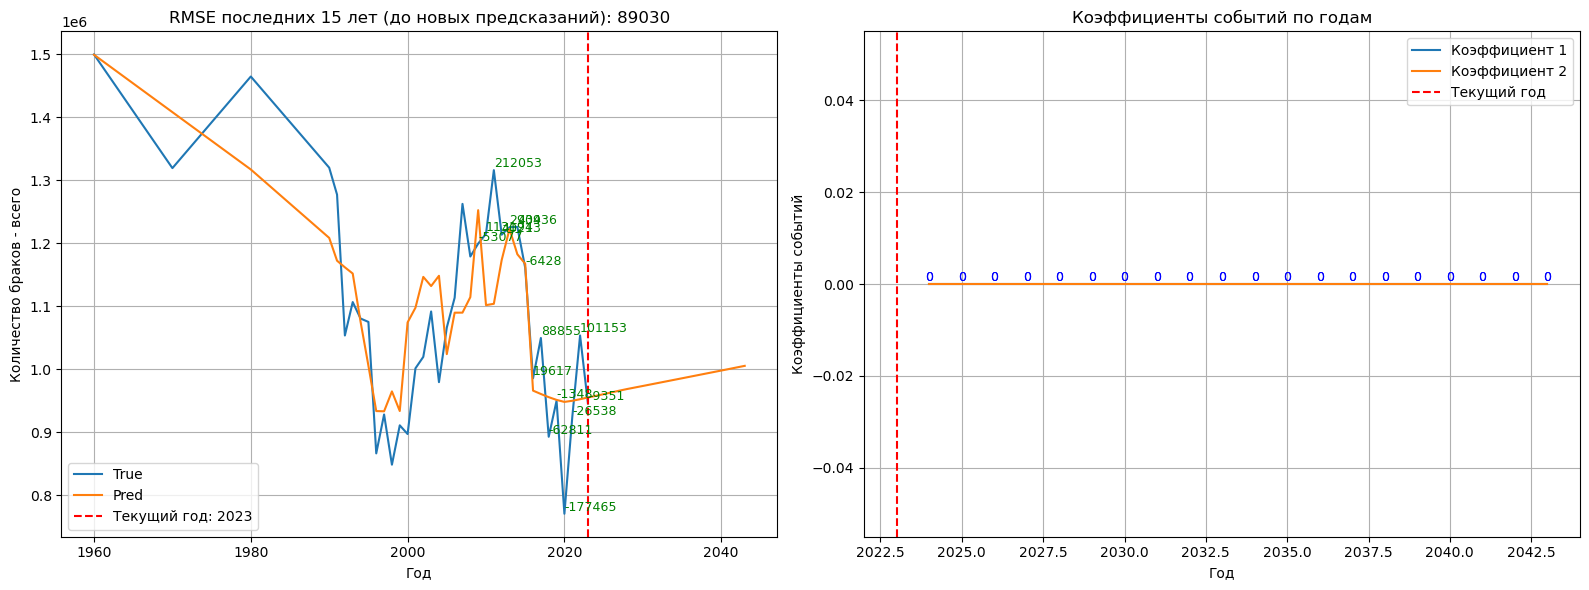

In [73]:
# Генерация новых лет для лучших параметров
new_years = generate_years(int(df['годы'].max()), 20, best_case_number, coef_df)
x, y, scaler_x, scaler_y, device = prepare_data(df, best_case_number)
# Построение результатов
plot_results(model, x, y, new_years)